In [3]:
import torch
import torchvision
from diffusers import DDPMScheduler, UNet2DModel, UNet2DConditionModel
from torch.optim.lr_scheduler import ReduceLROnPlateau
from matplotlib import pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm
import sys
import requests
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\PC\Desktop\ML_Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
class PhysicsDataset(torch.utils.data.Dataset):
    """
    one element: (energy deposit, (point, momentum))
    """
    def __init__(self, energy: torch.Tensor, condition: torch.Tensor,
                 transform=None, inverse_transform=None) -> None:
        self.transform = transform
        self.inverse_transform = inverse_transform  # for outer use

        if transform is not None:
            energy = self.transform(energy)

        self.energy = energy
        self.physic_condition = condition

    def __getitem__(self, idx: int) -> tuple:
        return self.energy[idx], self.physic_condition[idx]

    def __len__(self) -> int:
        return self.energy.shape[0]

# принимают batch-и x-ов
def log1p_transform(x: torch.Tensor):
    return torch.log1p(x)


def log1p_inverse_transform(x: torch.Tensor):
    return torch.expm1(x)

def get_physics_dataset(path: str, train: bool = True, val_ratio: float = 0.5,
                        log1p_energy: bool = True) -> torch.utils.data.Dataset:

    """
    Получение данных из файла .npz и формирование датасета для обучения. 
    Данные получаются из файла все, но на обучение идет только импульс и координаты
    """
    TRAIN_VAL_SPLIT_SEED = 0x3df3fa

    data_train = np.load(path)

    np.random.seed(TRAIN_VAL_SPLIT_SEED)
    dataset_size = len(data_train['EnergyDeposit'])
    val_size = int(dataset_size * val_ratio)

    all_indices = np.arange(dataset_size)
    val_indices = np.random.choice(all_indices, size=val_size, replace=False)
    val_mask = np.zeros(dataset_size, dtype=bool)
    val_mask[val_indices] = True
    train_indices = all_indices[~val_mask]
    indices = train_indices if train else val_indices

    energy = torch.tensor(data_train['EnergyDeposit'][indices]).float()
    energy = torch.permute(energy, dims=(0, 3, 1, 2))
    
    momentum = torch.tensor(data_train['ParticleMomentum'][indices]).float()
    momentum_norm = momentum / torch.norm(momentum, dim=1, keepdim=True) # нормировка
    pt = np.sqrt(momentum[:, 0]**2 + momentum[:, 1]**2)
    eta = - np.log(pt/momentum[:, 2])
    phi = np.arctan2(momentum[:, 0], momentum[:, 1])
    momentum_cyl = torch.stack([pt, eta, phi], dim=1) 
    
    total_energy_sci = torch.tensor(data_train['TotalEnergySci'][indices]).float()
    total_energy_sci_min_val = total_energy_sci.min()
    total_energy_sci_max_val = total_energy_sci.max()
    total_energy_sci_norm = (total_energy_sci/total_energy_sci_max_val).unsqueeze(1)  # [0, 1]

    total_energy_absorb = torch.tensor(data_train['TotalEnergyAbsorb'][indices]).float()
    total_energy_absorb_min_val = total_energy_absorb.min()
    total_energy_absorb_max_val = total_energy_absorb.max()
    total_energy_absorb_norm = (total_energy_absorb/total_energy_absorb_max_val).unsqueeze(1)  # [0, 1]

    point = torch.tensor(data_train['ParticlePoint'][indices]).float()
    point_norm = point / torch.norm(point, dim=1, keepdim=True) # нормировка

    
    
    physic_condition = torch.cat([momentum_norm,
                                  momentum_cyl,
                                    point_norm
                                    ], dim=1)  # (N, 8)
    transform, inverse_transform = None, None
    if log1p_energy:
        transform = log1p_transform
        inverse_transform = log1p_inverse_transform

    return PhysicsDataset(energy,
                          physic_condition,
                          transform=transform, inverse_transform=inverse_transform)

In [3]:
data_filepath = r"C:\Users\PC\Desktop\ML_Projects\data\caloGAN_case11_5D_120K.npz"
train_dataset = get_physics_dataset(data_filepath, train=True)
valid_dataset = get_physics_dataset(data_filepath, train=False)

C:\Users\PC\AppData\Local\Temp\ipykernel_4292\3403089306.py:57: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pt = np.sqrt(momentum[:, 0]**2 + momentum[:, 1]**2)
C:\Users\PC\AppData\Local\Temp\ipykernel_4292\3403089306.py:58: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  eta = - np.log(pt/momentum[:, 2])
C:\Users\PC\AppData\Local\Temp\ipykernel_4292\3403089306.py:59: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  phi = np.arctan2(momentum[:, 0], momentum[:, 1])


In [15]:
# Увеличьте размер батча для инференса, если позволяет видеопамять (VRAM).
# При инференсе не нужно хранить градиенты, поэтому батч может быть больше, чем при обучении.
infer_batch_size = 64 # Попробуйте 32, 64 или 128

train_loader = DataLoader(
    train_dataset, 
    batch_size=8, 
    shuffle=True,
    num_workers=4,        # Асинхронная загрузка данных (зависит от ядер CPU, обычно 4-8)
    pin_memory=True,      # Ускоряет перенос тензоров из RAM в VRAM
    prefetch_factor=2     # Предзагрузка батчей (работает только при num_workers > 0)
)

num_batches = 100
num_samples = infer_batch_size * num_batches 
valid_subset = Subset(valid_dataset, indices=range(min(num_samples, len(valid_dataset))))

valid_loader = DataLoader(
    valid_subset, 
    batch_size=infer_batch_size, 
    shuffle=False,        # Для инференса/валидации перемешивание не нужно, это лишняя трата CPU
    num_workers=0,        # Обязательно для загрузки данных в фоне
    pin_memory=True       # Критично для скорости передачи на GPU
)

In [5]:
sys.path.append('Calolib')
from pipeline.metrics import *
from pipeline.physical_metrics.calogan_prd import get_energy_embedding
from pipeline.physical_metrics import calogan_metrics
from pipeline.physical_metrics.prd_score import compute_prd_from_embedding, prd_to_max_f_beta_pair
from pipeline import calodiff
from visualization_aux.visualize_physics import energy_imshow 

In [7]:
class ConditionedUNet(nn.Module):
    def __init__(
        self, 
        image_size: int = 30, 
        cond_emb_size: int = 9, 
        cross_attention_dim: int = 128,
        layers_per_block: int = 2,
        block_out_channels: tuple = (32, 64, 128),
        down_block_types: tuple = ("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
        up_block_types: tuple = ("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        norm_num_groups: int = 32
    ):
        """
        A UNet model conditioned via cross-attention with configurable architecture.
        """
        super().__init__()

        self.image_size = image_size
        self.cond_emb_size = cond_emb_size
        self.internal_size = image_size + 2
        
        self.cond_projection = nn.Linear(cond_emb_size, cross_attention_dim)
        
        self.model = UNet2DConditionModel(
            sample_size=self.internal_size,
            in_channels=1,
            out_channels=1,
            layers_per_block=layers_per_block,
            block_out_channels=block_out_channels,
            down_block_types=down_block_types,
            up_block_types=up_block_types,
            cross_attention_dim=cross_attention_dim,
            norm_num_groups=norm_num_groups
        )

    def forward(self, x, t, condition):
        bs = x.shape[0]
        padded_x = torch.nn.functional.pad(x, (1, 1, 1, 1)) # [bs, 1, 32, 32]
        
        condition_emb = self.cond_projection(condition)
        condition_emb = condition_emb.view(bs, 1, -1)
        
        predicted_noise = self.model(
            sample=padded_x,
            timestep=t,
            encoder_hidden_states=condition_emb
        ).sample
        
        return predicted_noise[:, :, 1:-1, 1:-1]

In [ ]:
MODEL_CONFIGS = {
    "model_2": {
        "layers_per_block": 1,
        "block_out_channels": (32, 64, 128),
        "down_block_types": ("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
        "up_block_types": ("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        "norm_num_groups": 32,
        "cross_attention_dim": 128
    },
    "model_3": {
        "layers_per_block": 1,
        "block_out_channels": (24, 48, 96),
        "down_block_types": ("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
        "up_block_types": ("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
        "norm_num_groups": 24,
        "cross_attention_dim": 128
    },
    "model_5": {
        "layers_per_block": 1,
        "block_out_channels": (4, 8, 16),
        "down_block_types": ("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
        "up_block_types": ("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
        "norm_num_groups": 4,
        "cross_attention_dim": 16
    },
    "model_4": {
        "layers_per_block": 1,
        "block_out_channels": (8, 16, 32),
        "down_block_types": ("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
        "up_block_types": ("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
        "norm_num_groups": 4,
        "cross_attention_dim": 128
    }
}

MODEL_PATHS = {'model_1': r'C:\Users\PC\Desktop\ML_Projects\data\best_model_on_train_rmsprop.pth',
               'model_2': r"C:\Users\PC\Desktop\ML_Projects\best_model_on_train_UNET div 2.pth",
               'model_3': r"C:\Users\PC\Desktop\ML_Projects\best_model_on_train_UNET div 5.pth",
               'model_4': r"C:\Users\PC\Desktop\ML_Projects\best_model_on_train_UNET div 50.pth",
               'model_5': r"C:\Users\PC\Desktop\ML_Projects\best_model_on_train_UNET div 100.pth"
              }

generated_images = sample(
                model, 
                y_test, 
                n_inference_steps, 
                device,
                noise_scheduler_fn, 
                shape=x_test_real.shape[1:],
                sampling_method="ddim" 
                  )

Evaluating model_2...
Start Inference: Steps=100, Specific Steps=None, Save All=False


Inference and Saving: 100%|██████████| 100/100 [03:00<00:00,  1.81s/it]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_2_linear_steps_100.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9717
PRD Physics AUC: -0.9091
------------------------------------


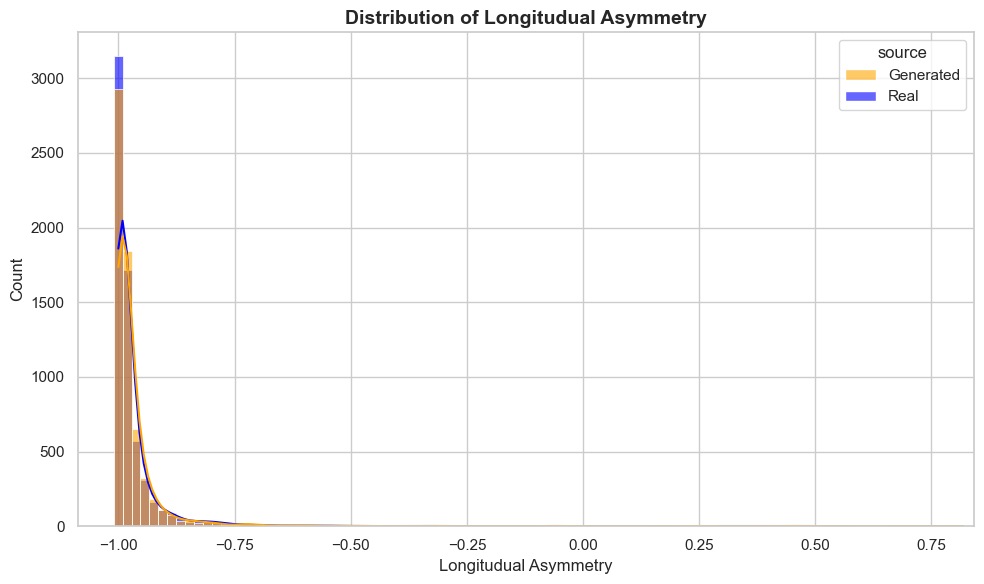

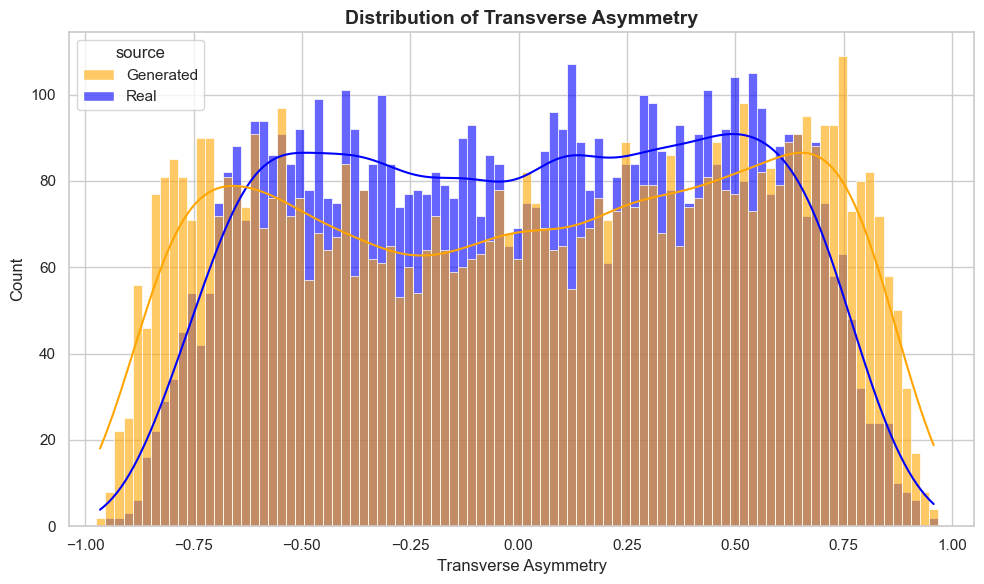

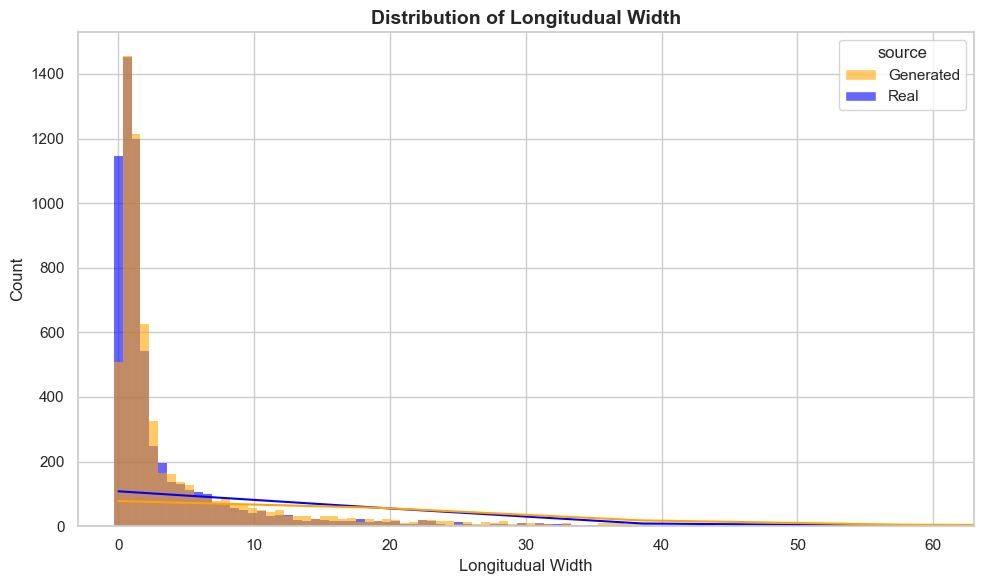

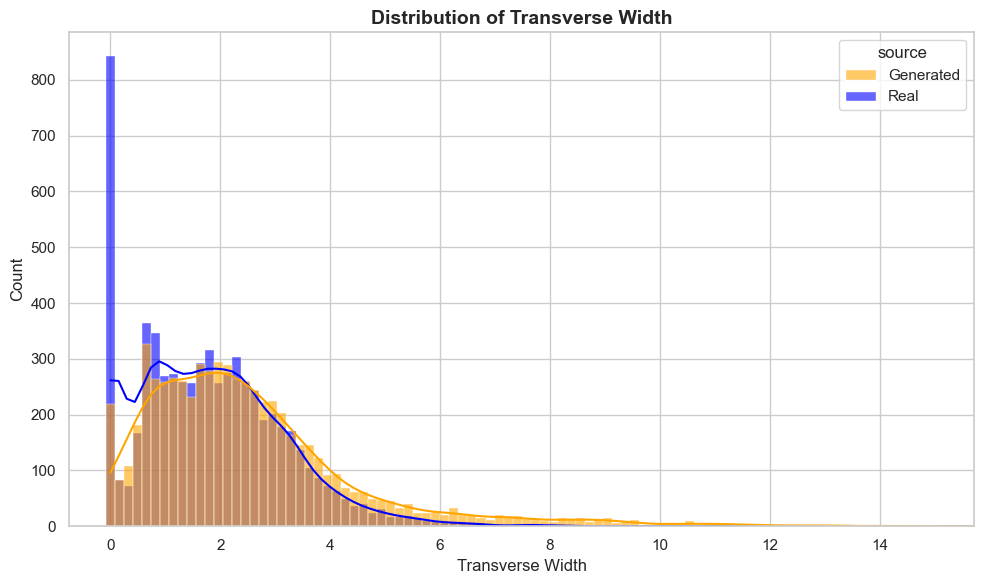

Energy PRD Curve


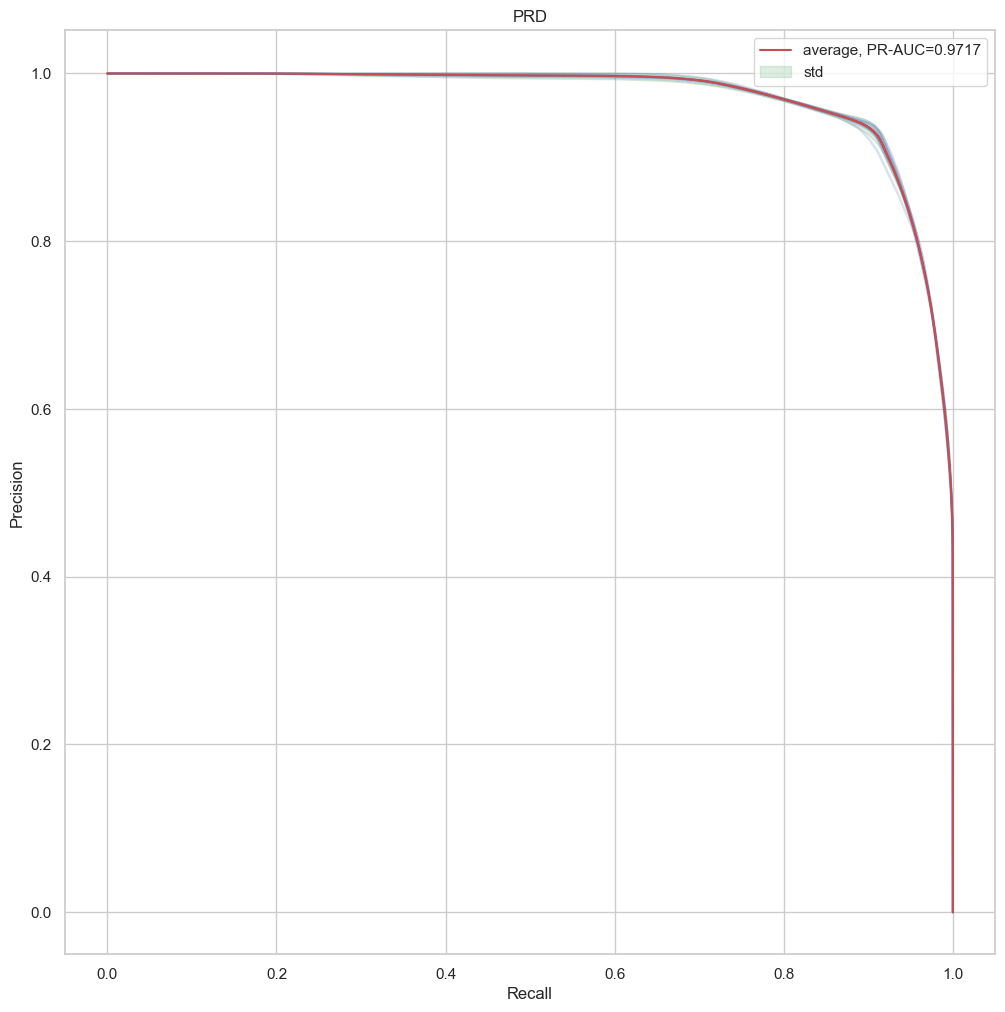

Physics PRD Curve


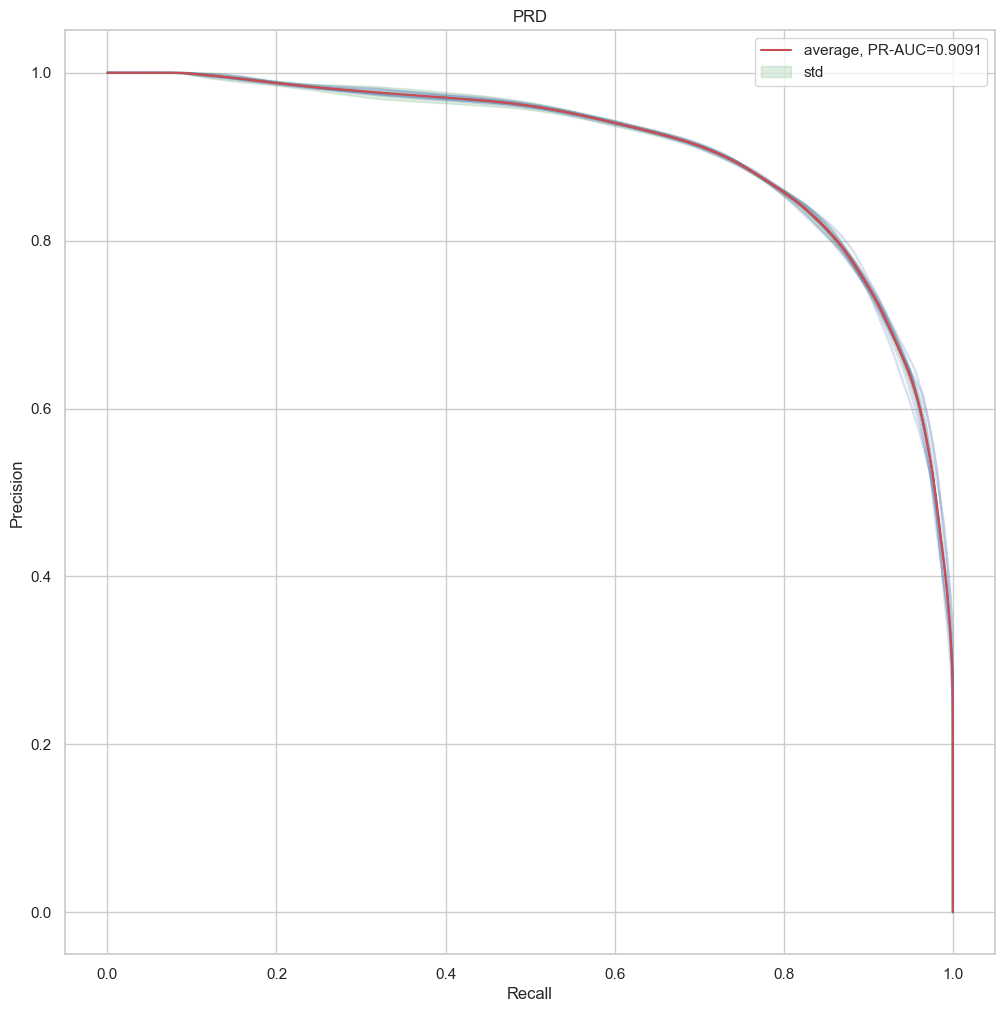

Evaluating model_3...
Start Inference: Steps=100, Specific Steps=None, Save All=False


Inference and Saving: 100%|██████████| 100/100 [02:18<00:00,  1.39s/it]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_3_linear_steps_100.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9623
PRD Physics AUC: -0.9045
------------------------------------


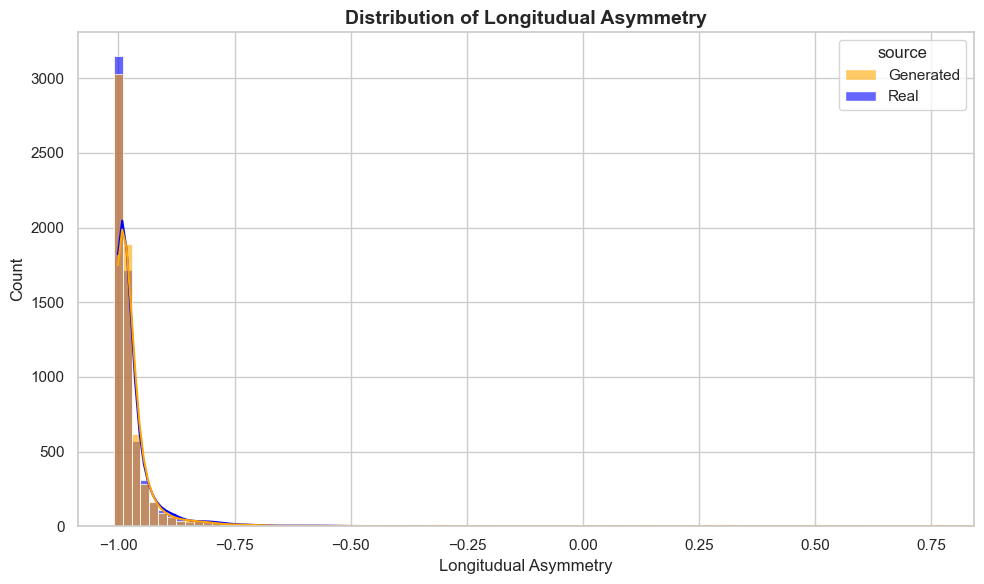

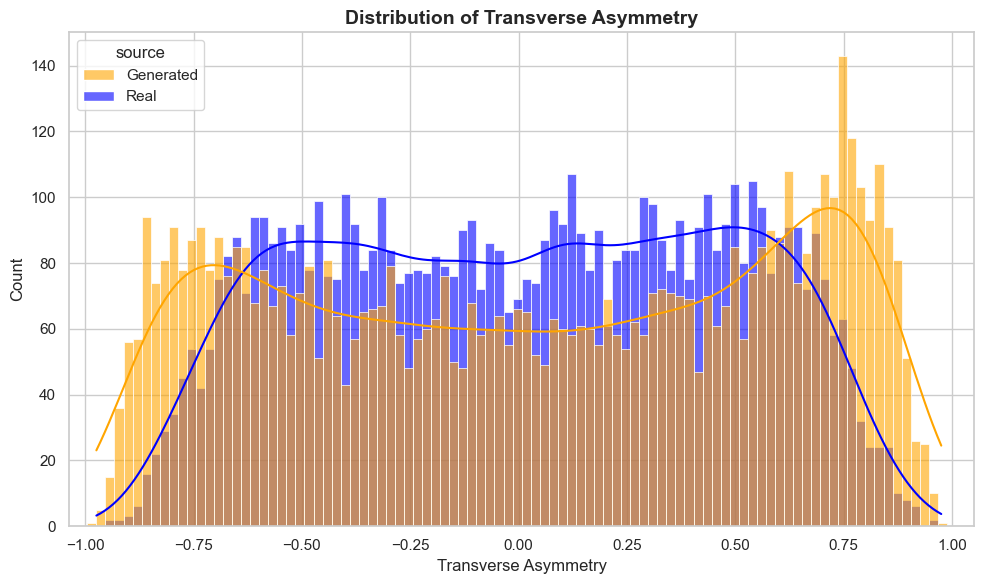

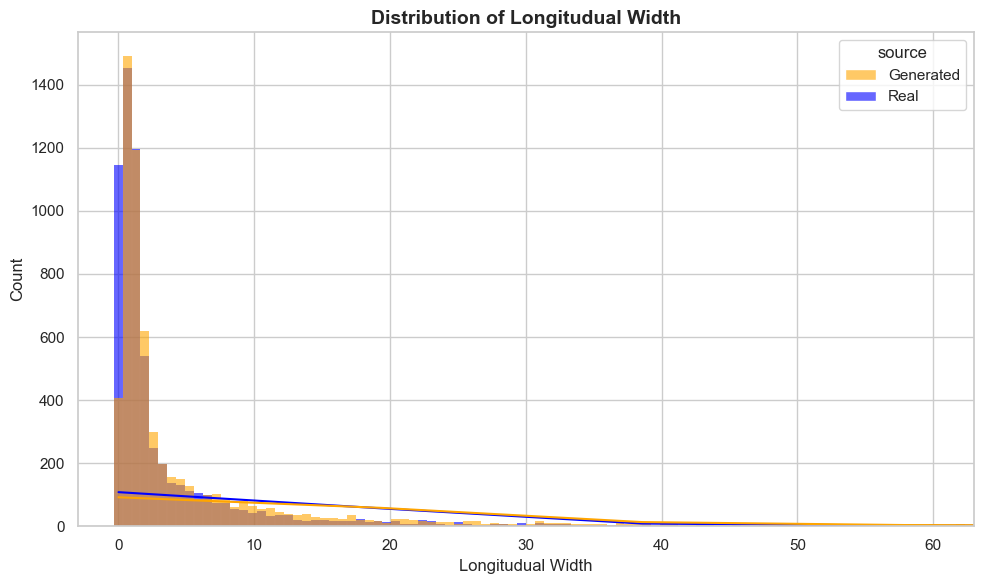

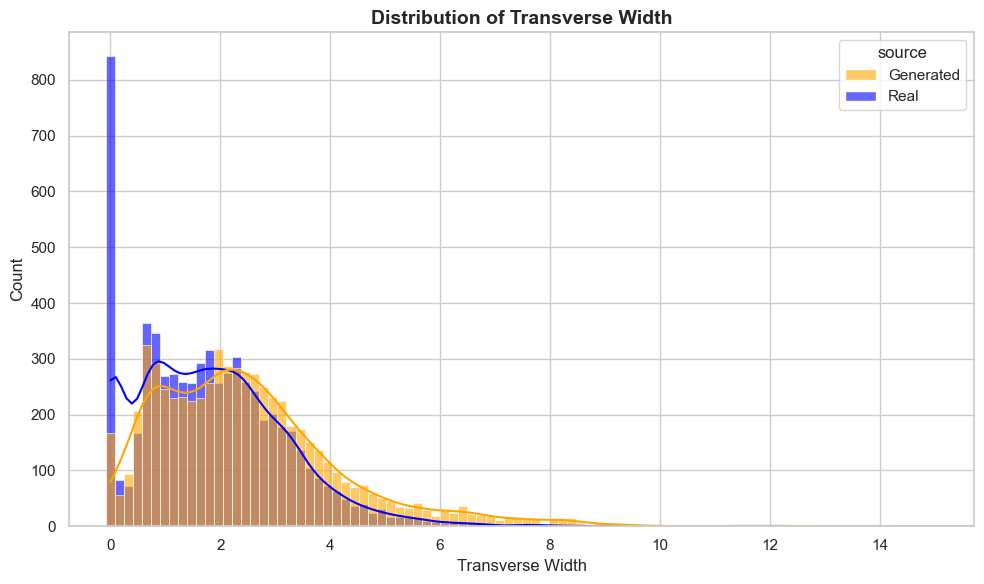

Energy PRD Curve


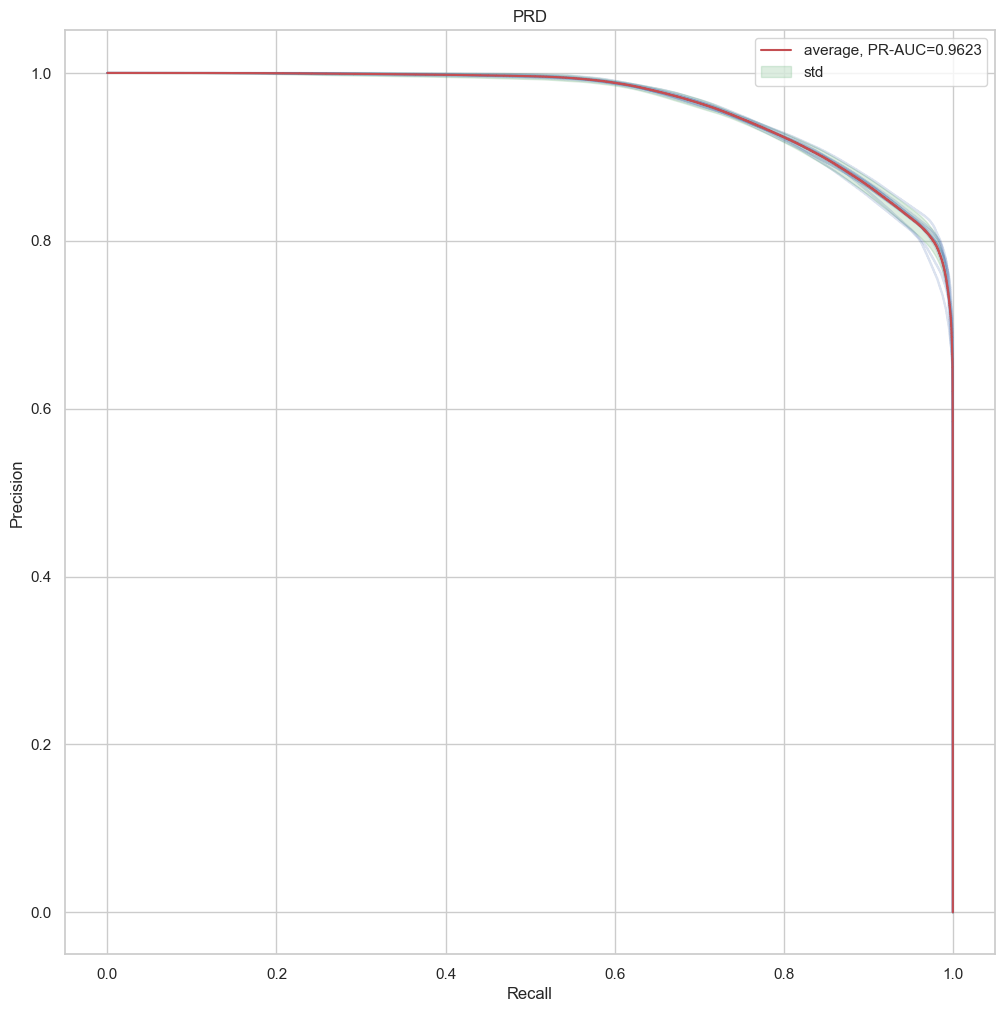

Physics PRD Curve


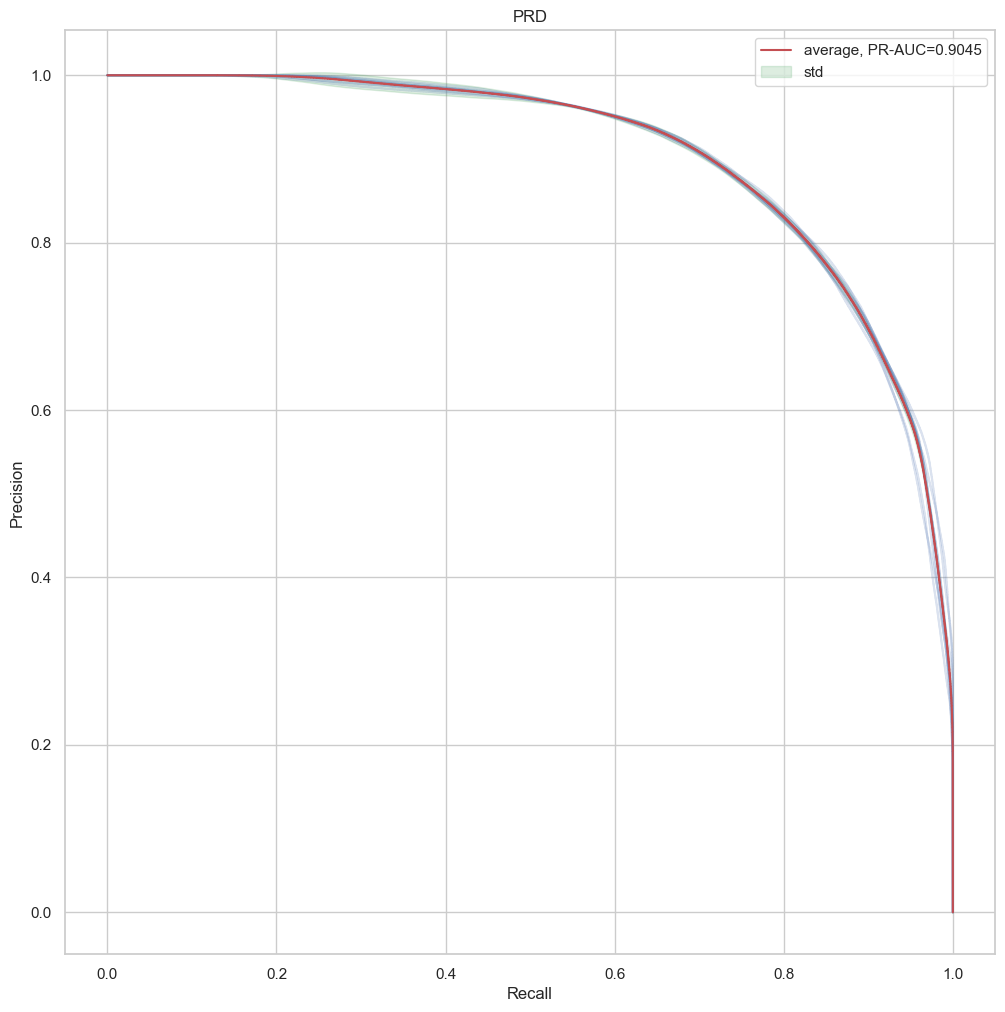

Evaluating model_4...


RuntimeError: Error(s) in loading state_dict for ConditionedUNet:
	Unexpected key(s) in state_dict: "total_ops", "total_params", "model.total_ops", "model.total_params", "model.time_proj.total_ops", "model.time_proj.total_params", "model.time_embedding.total_ops", "model.time_embedding.total_params", "model.time_embedding.act.total_ops", "model.time_embedding.act.total_params", "model.down_blocks.total_ops", "model.down_blocks.total_params", "model.down_blocks.0.total_ops", "model.down_blocks.0.total_params", "model.down_blocks.0.resnets.total_ops", "model.down_blocks.0.resnets.total_params", "model.down_blocks.0.resnets.0.total_ops", "model.down_blocks.0.resnets.0.total_params", "model.down_blocks.0.resnets.0.norm1.total_ops", "model.down_blocks.0.resnets.0.norm1.total_params", "model.down_blocks.0.resnets.0.norm2.total_ops", "model.down_blocks.0.resnets.0.norm2.total_params", "model.down_blocks.0.resnets.0.nonlinearity.total_ops", "model.down_blocks.0.resnets.0.nonlinearity.total_par

In [ ]:
n_total = 100
scenario_scheduling = 'linear'
results = {
    name_model: {
        'complexity': None,
        'powers': [], 
        'PRD_energy_AUC': [],
        'PRD_physics_AUC': [],
        'PRD_energy_AUC_std': [],
        'PRD_physics_AUC_std': []
    } 
    for name_model in MODEL_CONFIGS.keys()
}


for name, config in MODEL_CONFIGS.items():
    print(f"Evaluating {name}...")
    
    model = ConditionedUNet(**config).to(device)
    checkpoint = torch.load(MODEL_PATHS[name], weights_only=True)
    model.load_state_dict(checkpoint)
    
    results[name]['complexity'] = calodiff.analyze_model_complexity(model, batch_size=1, n_steps=n_total)
    
    file_name = f"inference_results_{name}_{scenario_scheduling}_steps_{n_total}.npz"
    filename = os.path.join("inference_results", file_name)
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    calodiff.inference_with_saving(
        model=model,
        dataloader=valid_loader,
        n_steps=n_total,
        sampling_method='ddim', 
        device=device, # <-- Заменил "cuda" на переменную device для консистентности
        output_path=filename,
        save_all_steps=False
    )

    with np.load(filename) as new_data:
        images = new_data['images']
        labels = new_data['labels']
        conditions = new_data['conditions']
    
    images_tensor = torch.tensor(images, dtype=torch.float32)
    images_original_scale = torch.expm1(images_tensor)
    labels_tensor = torch.tensor(labels)
    
    real_mask = (labels_tensor == 1)
    generated_mask = (labels_tensor == 0)
    
    real_images = images_original_scale[real_mask]
    generated_images = images_original_scale[generated_mask]
    conditions_for_metrics = torch.tensor(conditions[generated_mask], dtype=torch.float32) 
    
    metrics = calodiff.evaluate_and_visualize_physics_metrics(
        gen_images=generated_images,
        real_images=real_images,
        conditions=conditions_for_metrics
    )

    
    auc_energy, current_prd_auc_energy_std = calodiff.calculate_pr_metrics(metrics['precision_energy'], metrics['recall_energy'])
    auc_physics, current_prd_auc_physics_std = calodiff.calculate_pr_metrics(metrics['precision_physics'], metrics['recall_physics'])
    
    results[name]['PRD_energy_AUC'].append(auc_energy)
    results[name]['PRD_physics_AUC'].append(auc_physics)
    results[name]['PRD_energy_AUC_std'].append(current_prd_auc_energy_std)
    results[name]['PRD_physics_AUC_std'].append(current_prd_auc_physics_std)

print("Evaluation complete!")

Evaluating model_5...
Start Inference: Steps=100, Specific Steps=None, Save All=False


Inference and Saving: 100%|██████████| 100/100 [02:28<00:00,  1.49s/it]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_5_linear_steps_100.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9212
PRD Physics AUC: -0.9670
------------------------------------


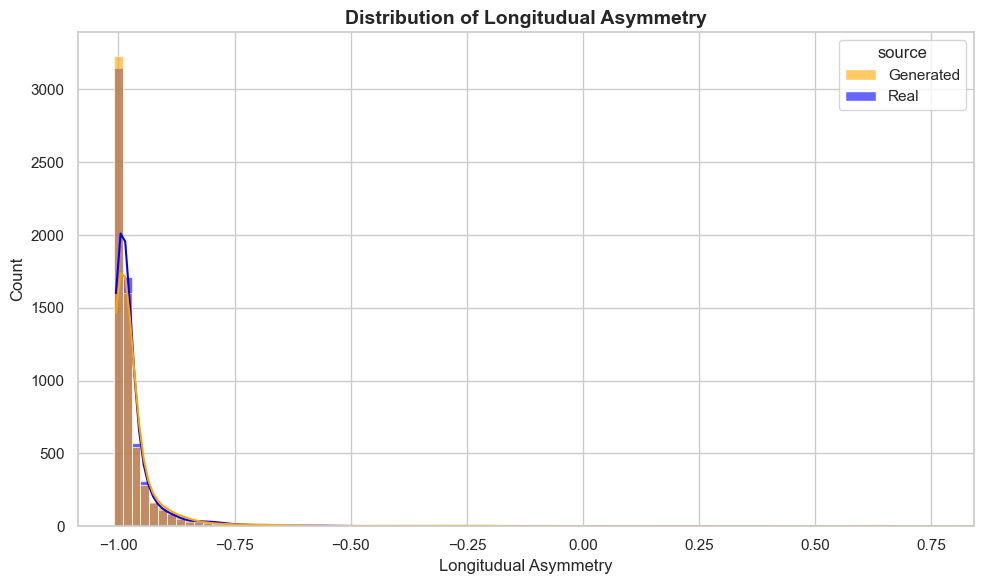

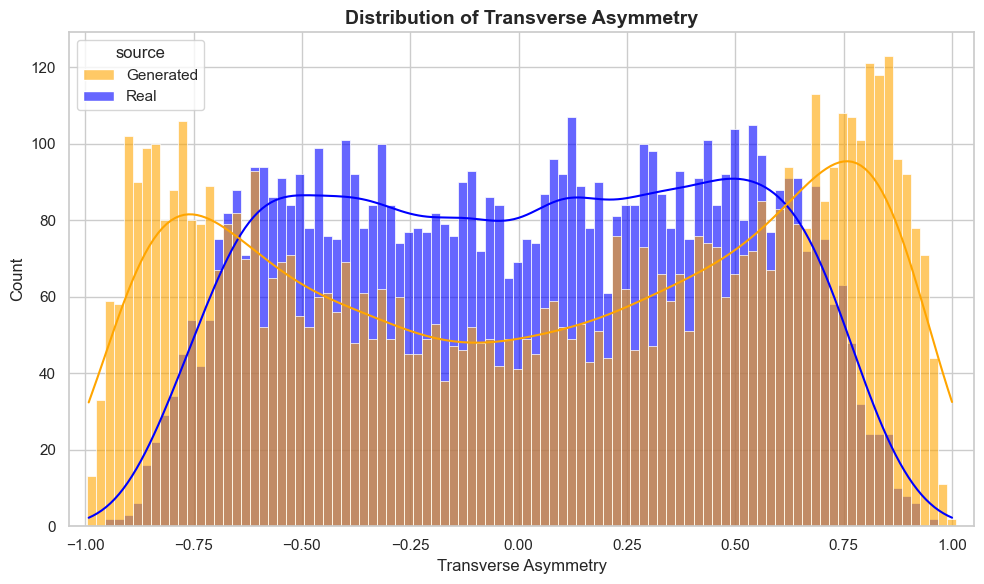

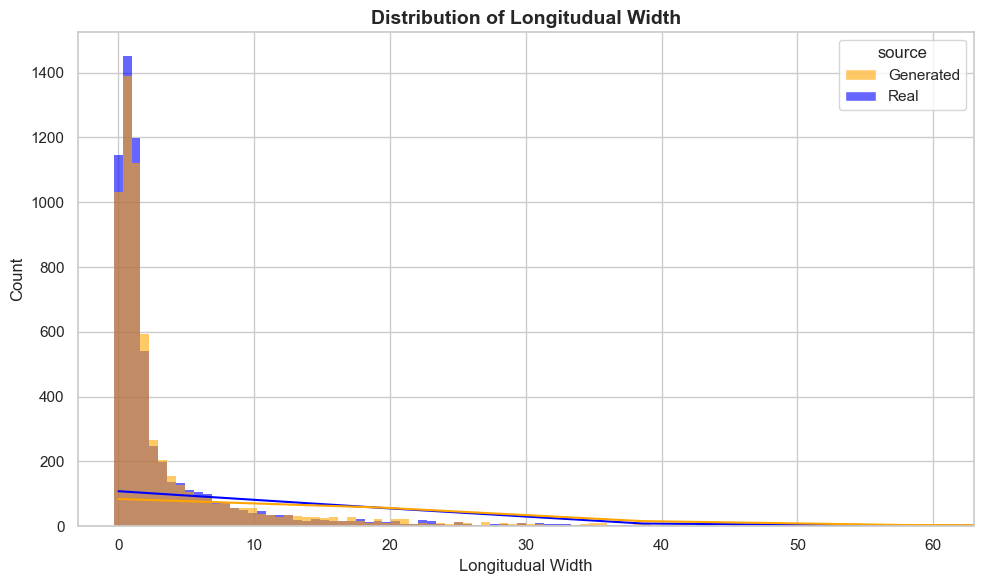

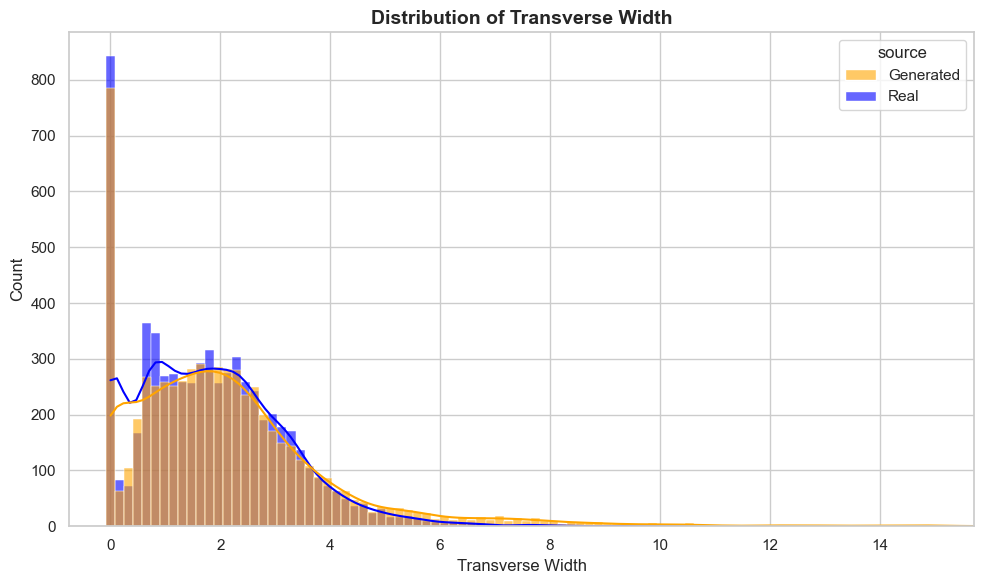

Energy PRD Curve


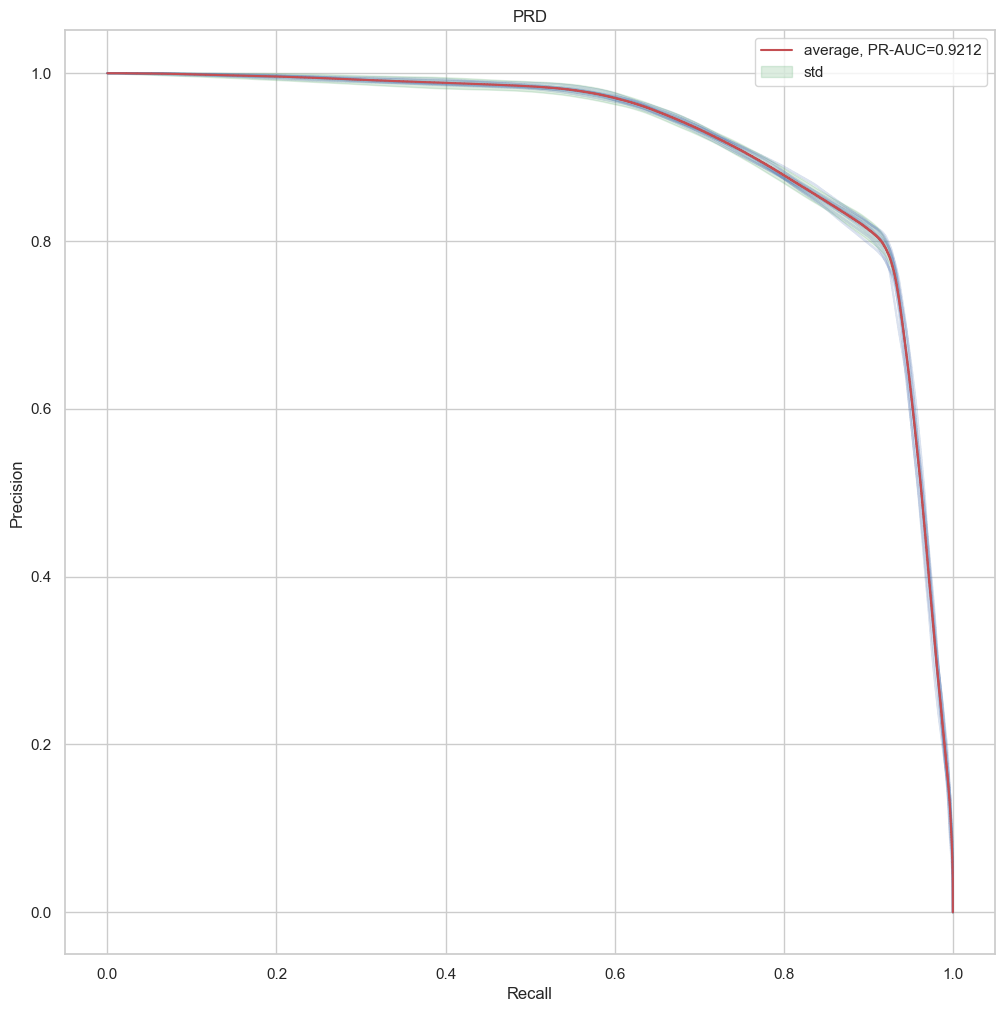

Physics PRD Curve


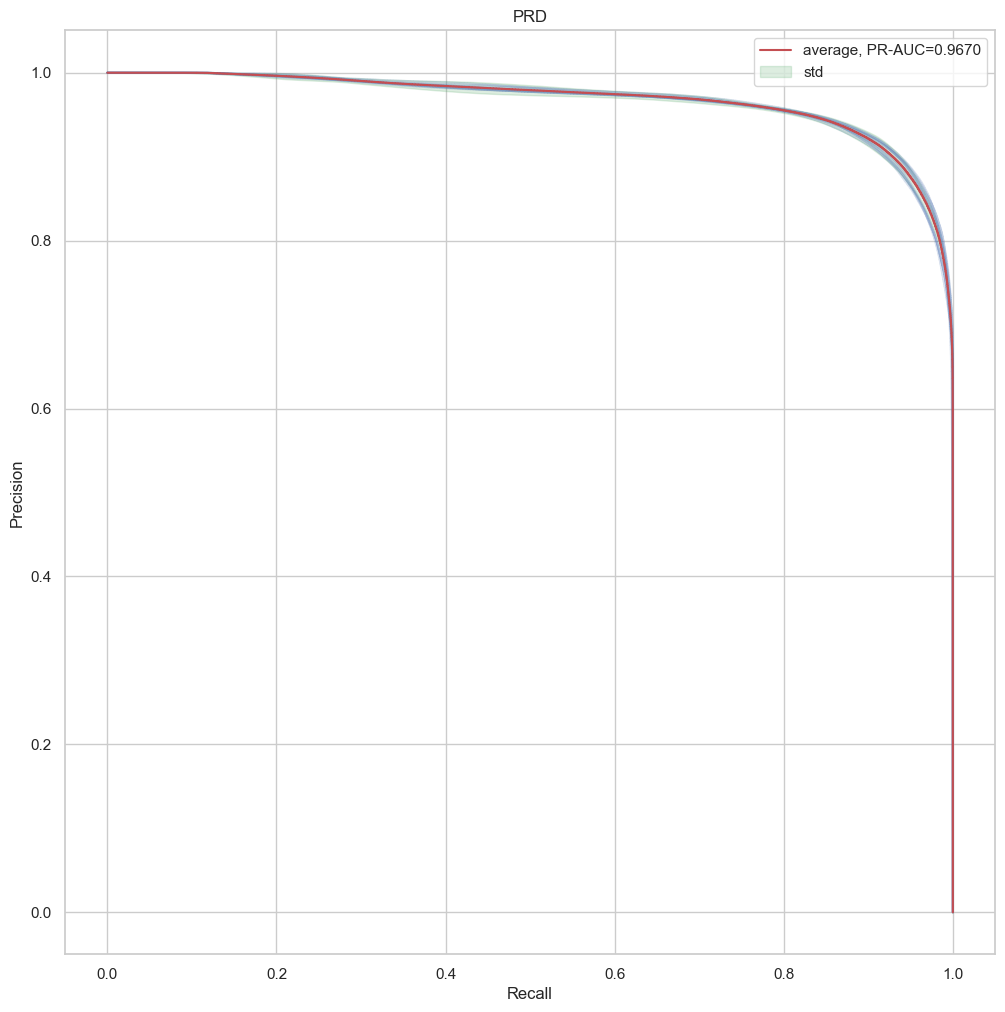

Evaluating model_4...
Start Inference: Steps=100, Specific Steps=None, Save All=False


Inference and Saving: 100%|██████████| 100/100 [02:20<00:00,  1.40s/it]


Данные (только финал) сохранены в: 'inference_results\inference_results_model_4_linear_steps_100.npz'


c:\Users\PC\Desktop\ML_Projects\Calolib\pipeline\physical_metrics\calogan_metrics.py:83: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sum_2 - sum_1 * sum_1)


--- Результаты Физических Метрик ---
PRD Energy AUC: -0.9492
PRD Physics AUC: -0.9870
------------------------------------


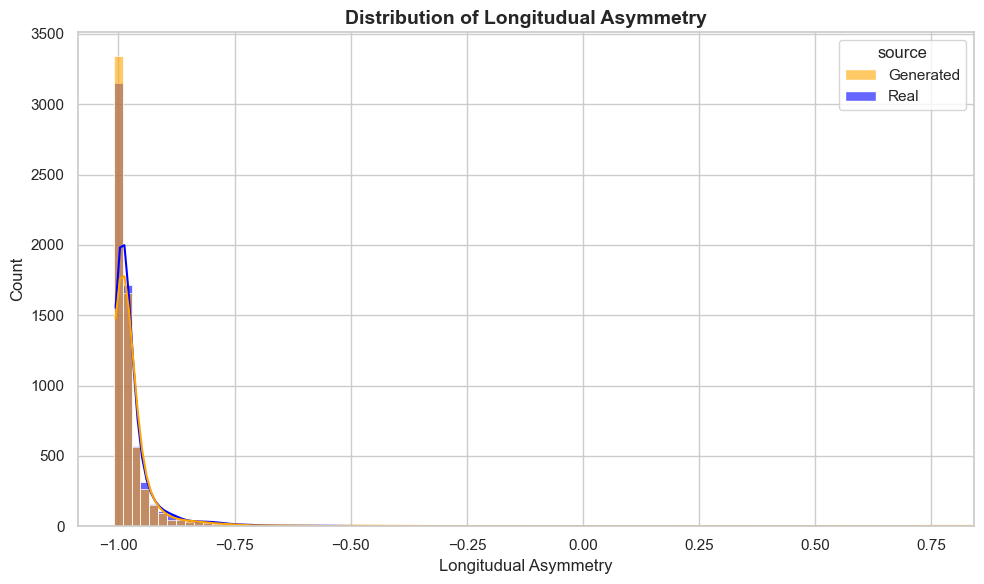

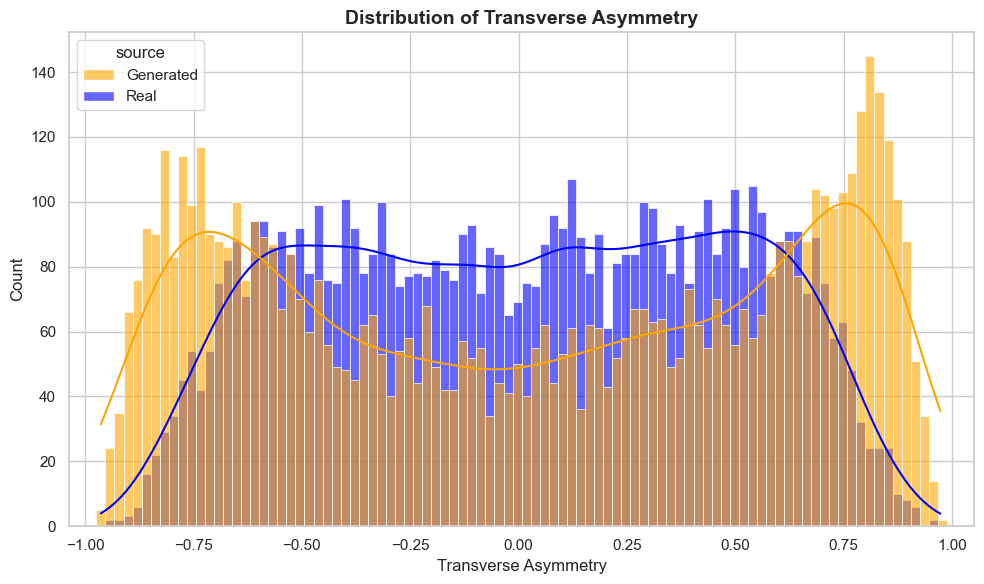

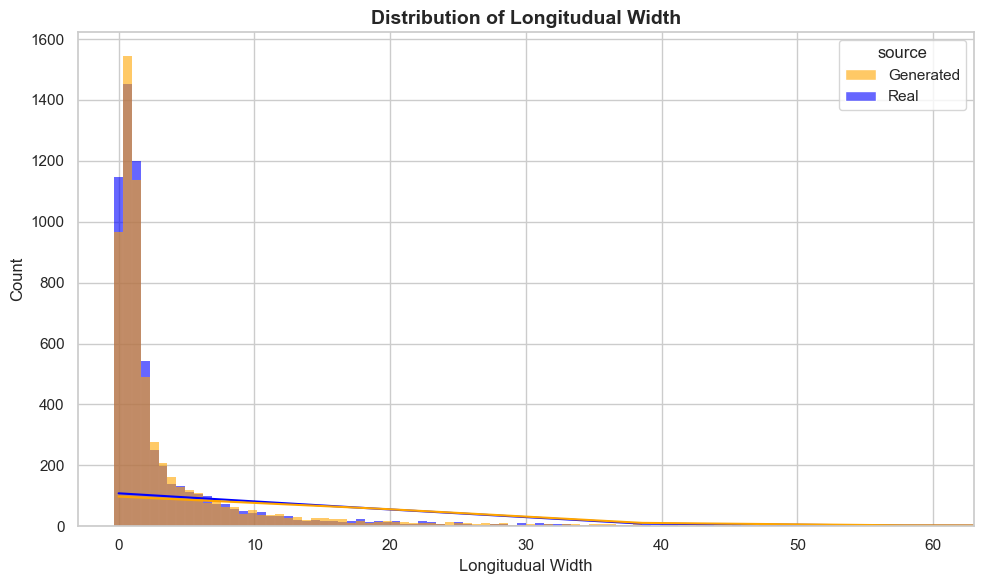

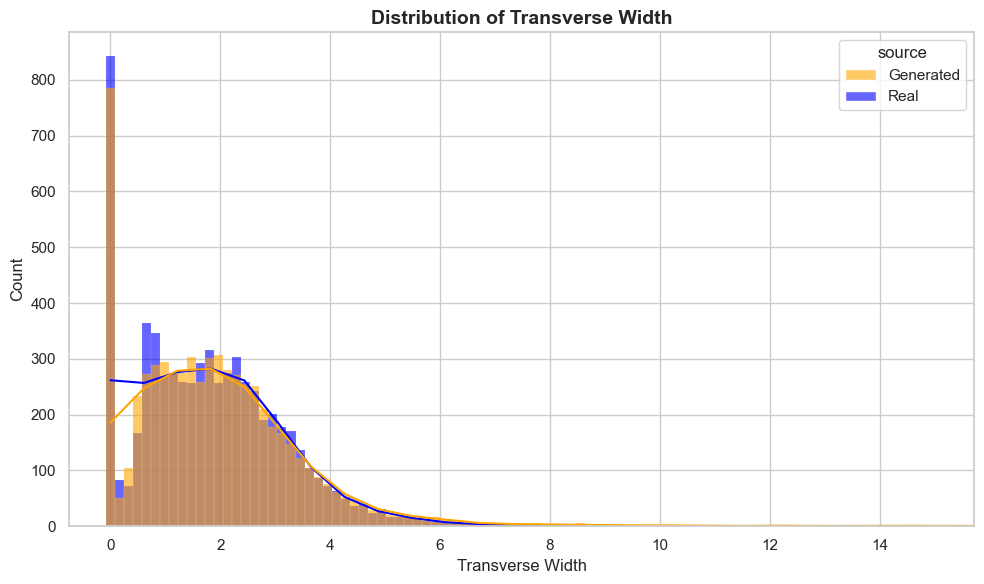

Energy PRD Curve


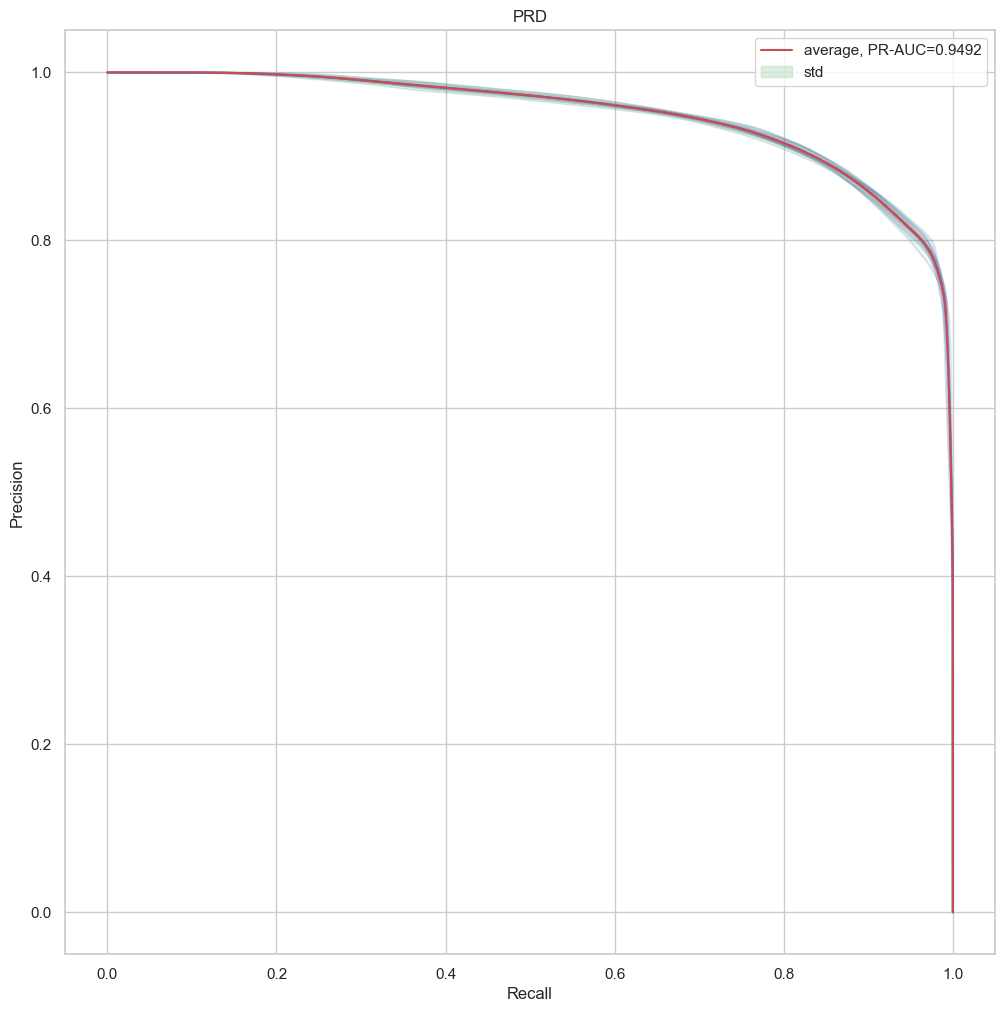

Physics PRD Curve


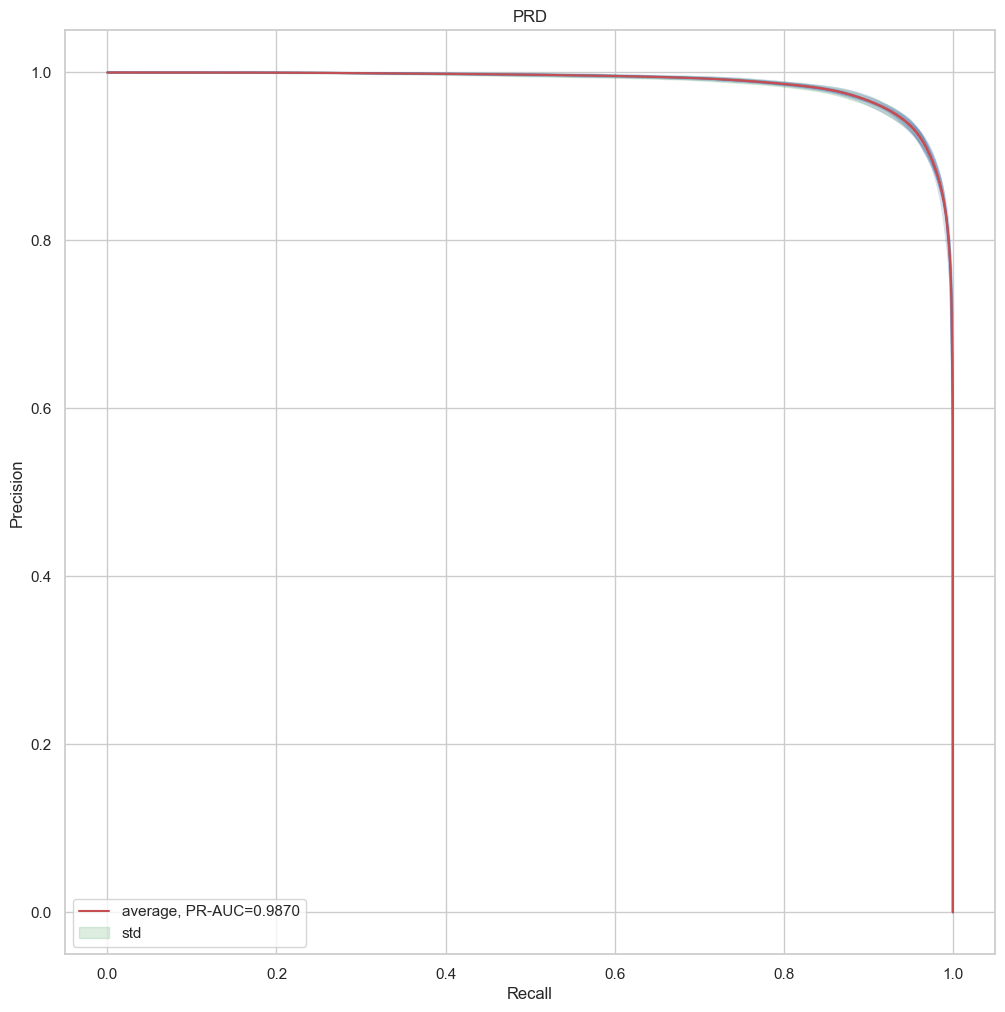

Evaluation complete!


In [24]:
for name, config in MODEL_CONFIGS.items():
    if name == 'model_2' or name == 'model_3':
        continue
    print(f"Evaluating {name}...")
    
    model = ConditionedUNet(**config).to(device)
    checkpoint = torch.load(MODEL_PATHS[name], weights_only=True)
    model.load_state_dict(checkpoint, strict=False)
    
    results[name]['complexity'] = calodiff.analyze_model_complexity(model, batch_size=1, n_steps=n_total)
    
    file_name = f"inference_results_{name}_{scenario_scheduling}_steps_{n_total}.npz"
    filename = os.path.join("inference_results", file_name)
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    calodiff.inference_with_saving(
        model=model,
        dataloader=valid_loader,
        n_steps=n_total,
        sampling_method='ddim', 
        device=device, # <-- Заменил "cuda" на переменную device для консистентности
        output_path=filename,
        save_all_steps=False
    )

    with np.load(filename) as new_data:
        images = new_data['images']
        labels = new_data['labels']
        conditions = new_data['conditions']
    
    images_tensor = torch.tensor(images, dtype=torch.float32)
    images_original_scale = torch.expm1(images_tensor)
    labels_tensor = torch.tensor(labels)
    
    real_mask = (labels_tensor == 1)
    generated_mask = (labels_tensor == 0)
    
    real_images = images_original_scale[real_mask]
    generated_images = images_original_scale[generated_mask]
    conditions_for_metrics = torch.tensor(conditions[generated_mask], dtype=torch.float32) 
    
    metrics = calodiff.evaluate_and_visualize_physics_metrics(
        gen_images=generated_images,
        real_images=real_images,
        conditions=conditions_for_metrics
    )

    
    auc_energy, current_prd_auc_energy_std = calodiff.calculate_pr_metrics(metrics['precision_energy'], metrics['recall_energy'])
    auc_physics, current_prd_auc_physics_std = calodiff.calculate_pr_metrics(metrics['precision_physics'], metrics['recall_physics'])
    
    results[name]['PRD_energy_AUC'].append(auc_energy)
    results[name]['PRD_physics_AUC'].append(auc_physics)
    results[name]['PRD_energy_AUC_std'].append(current_prd_auc_energy_std)
    results[name]['PRD_physics_AUC_std'].append(current_prd_auc_physics_std)

print("Evaluation complete!")

In [27]:
model = ConditionedUNet().to(device)
checkpoint = torch.load('C:\\Users\\PC\\Desktop\\ML_Projects\\data\\best_model_on_train_rmsprop.pth', weights_only=True)
model.load_state_dict(checkpoint)

<All keys matched successfully>

In [ ]:
results['model_1'] ={
        'complexity': None,
        'powers': [], 
        'PRD_energy_AUC': [],
        'PRD_physics_AUC': [],
        'PRD_energy_AUC_std': [],
        'PRD_physics_AUC_std': []
    } 
results['model_1']['complexity'] = calodiff.analyze_model_complexity(model, batch_size=1, n_steps=n_total)


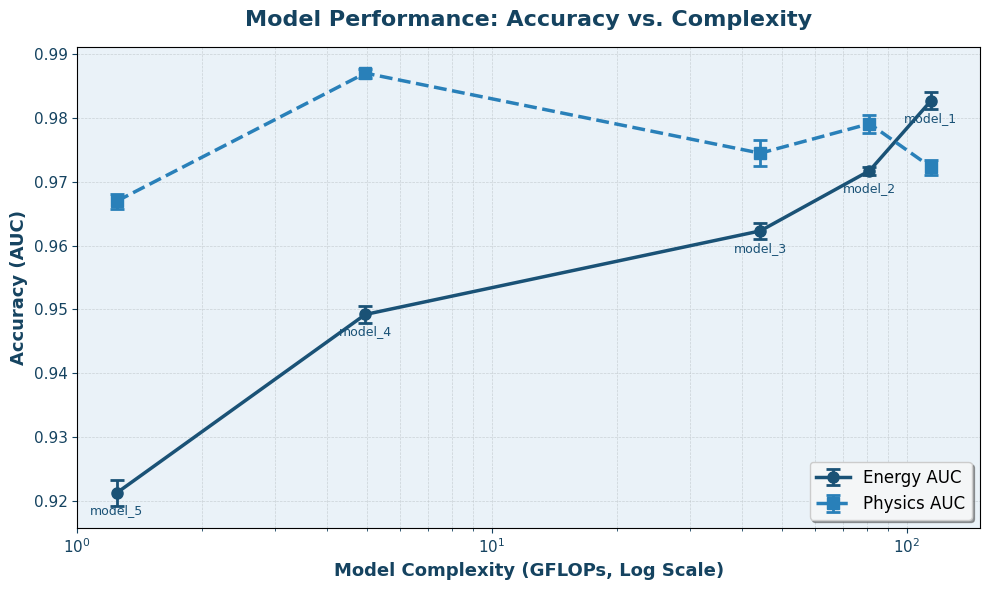

In [ ]:
data = []
for model, metrics in results.items():
    data.append({
        'Model': model,
        'Complexity': metrics['complexity'],
        'Energy_AUC': float(metrics['PRD_energy_AUC'][0]),
        'Energy_AUC_std': float(metrics['PRD_energy_AUC_std'][0]),
        'Physics_AUC': float(metrics['PRD_physics_AUC'][0]),
        'Physics_AUC_std': float(metrics['PRD_physics_AUC_std'][0])
    })

df = pd.DataFrame(data).sort_values(by='Complexity')

fig, ax = plt.subplots(figsize=(10, 6))

color_energy = '#1A5276'  
color_physics = '#2980B9'
color_bg = '#EAF2F8'      

ax.set_facecolor(color_bg)

ax.set_xscale('log')
ax.set_xlim(left=1, right = 150)

ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='#BDC3C7', alpha=0.7)

ax.errorbar(df['Complexity'], df['Energy_AUC'], yerr=df['Energy_AUC_std'], 
            fmt='-o', color=color_energy, label='Energy AUC', 
            capsize=5, capthick=2, elinewidth=2, markersize=8, linewidth=2.5)
            
ax.errorbar(df['Complexity'], df['Physics_AUC'], yerr=df['Physics_AUC_std'], 
            fmt='--s', color=color_physics, label='Physics AUC', 
            capsize=5, capthick=2, elinewidth=2, markersize=8, linewidth=2.5)

# Добавляем заголовки и подписи на английском
ax.set_title('Model Performance: Accuracy vs. Complexity', fontsize=16, fontweight='bold', color='#154360', pad=15)
ax.set_xlabel('Model Complexity (GFLOPs, Log Scale)', fontsize=13, fontweight='bold', color='#154360')
ax.set_ylabel('Accuracy (AUC)', fontsize=13, fontweight='bold', color='#154360')

# Настраиваем размер шрифта у осей (minor=True обновляет шрифт и для промежуточных делений лог-шкалы)
ax.tick_params(axis='both', which='both', labelsize=11, colors='#154360')

# Добавляем подписи названий моделей под точками Energy_AUC
for i, row in df.iterrows():
    ax.annotate(row['Model'], 
                (row['Complexity'], row['Energy_AUC']),
                textcoords="offset points", 
                xytext=(0,-15), 
                ha='center', fontsize=9, color=color_energy)

# Настраиваем легенду
legend = ax.legend(fontsize=12, loc='lower right', frameon=True, fancybox=True, shadow=True)
legend.get_frame().set_facecolor('#F4F6F7')

plt.tight_layout()
plt.show()

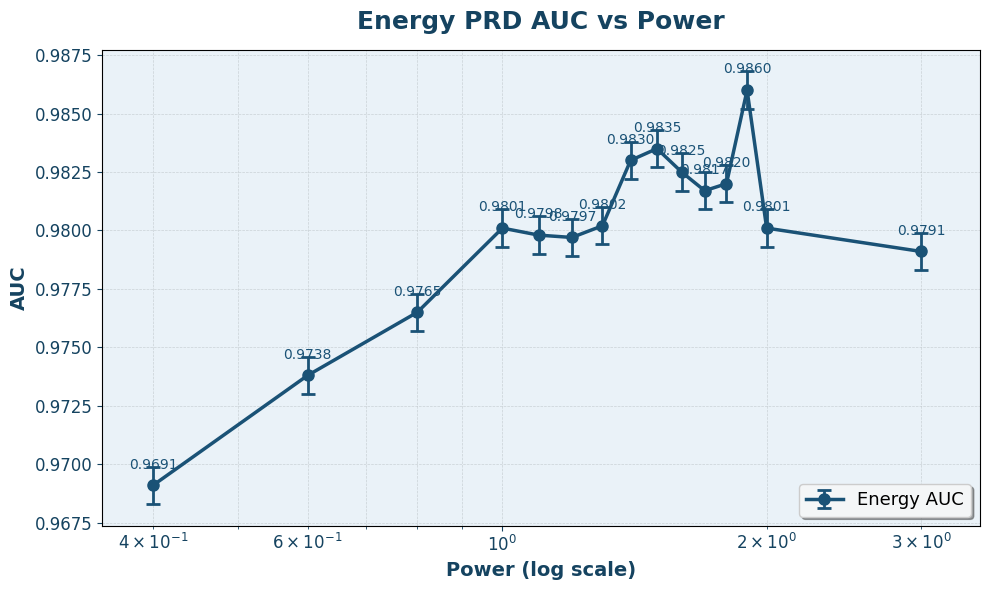

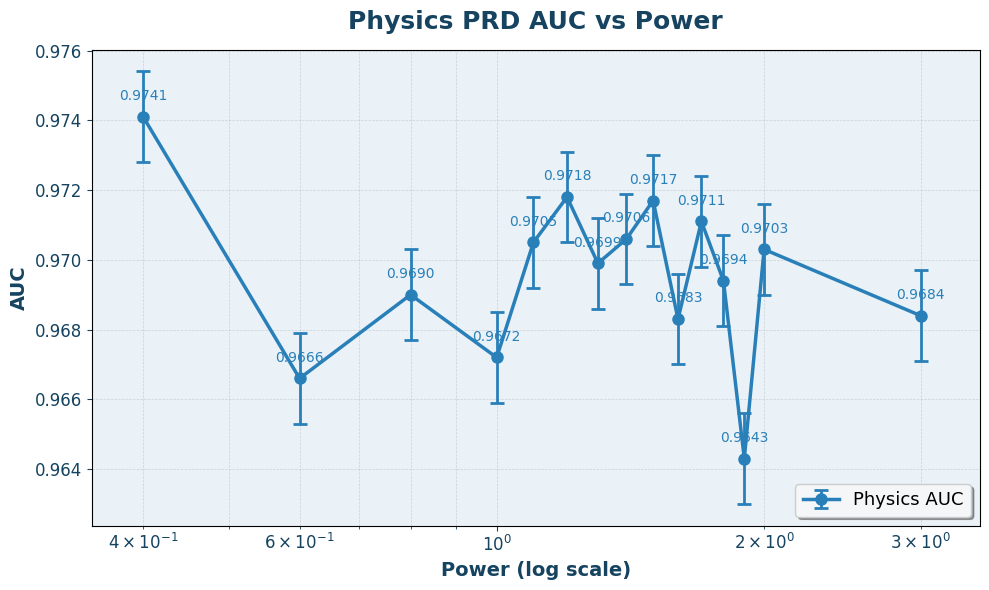

In [ ]:

color_energy = '#1A5276'  
color_physics = '#2980B9' 
color_bg = '#EAF2F8'      

fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_facecolor(color_bg)

ax1.set_xscale('log')
ax1.set_xlim(left=0.35, right=3.5) 
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, color='#BDC3C7', alpha=0.7)

ax1.errorbar(df['Power'], df['Energy_AUC'], yerr=df['Energy_AUC_std'], 
            fmt='-o', color=color_energy, label='Energy AUC', 
            capsize=5, capthick=2, elinewidth=2, markersize=8, linewidth=2.5)

ax1.set_title('Energy PRD AUC vs Power', fontsize=18, fontweight='bold', color='#154360', pad=15)
ax1.set_xlabel('Power (log scale)', fontsize=14, fontweight='bold', color='#154360')
ax1.set_ylabel('AUC', fontsize=14, fontweight='bold', color='#154360')
ax1.tick_params(axis='both', which='both', labelsize=12, colors='#154360')
for i, row in df.iterrows():
    ax1.annotate(f"{row['Energy_AUC']:.4f}", 
                (row['Power'], row['Energy_AUC']),
                textcoords="offset points", 
                xytext=(0, 12), # Смещение вверх
                ha='center', fontsize=10, color=color_energy)

legend1 = ax1.legend(fontsize=13, loc='lower right', frameon=True, fancybox=True, shadow=True)
legend1.get_frame().set_facecolor('#F4F6F7')
fig1.tight_layout()

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_facecolor(color_bg)
ax2.set_xscale('log')
ax2.set_xlim(left=0.35, right=3.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, color='#BDC3C7', alpha=0.7)

ax2.errorbar(df['Power'], df['Physics_AUC'], yerr=df['Physics_AUC_std'], 
            fmt='-o', color=color_physics, label='Physics AUC', 
            capsize=5, capthick=2, elinewidth=2, markersize=8, linewidth=2.5)

ax2.set_title('Physics PRD AUC vs Power', fontsize=18, fontweight='bold', color='#154360', pad=15)
ax2.set_xlabel('Power (log scale)', fontsize=14, fontweight='bold', color='#154360')
ax2.set_ylabel('AUC', fontsize=14, fontweight='bold', color='#154360')
ax2.tick_params(axis='both', which='both', labelsize=12, colors='#154360')

for i, row in df.iterrows():
    ax2.annotate(f"{row['Physics_AUC']:.4f}", 
                (row['Power'], row['Physics_AUC']),
                textcoords="offset points", 
                xytext=(0, 12), 
                ha='center', fontsize=10, color=color_physics)

legend2 = ax2.legend(fontsize=13, loc='lower right', frameon=True, fancybox=True, shadow=True)
legend2.get_frame().set_facecolor('#F4F6F7')
fig2.tight_layout()

plt.show()